# **Нелинейные модели против южной погоды**

---

**Описание исследования**

Необходимо построить модель машинного обучения для прогнозирования почасового спроса на аренду велосипедов по погодным и календарным условиям. Задача регрессии - предсказать числовое значение целевой переменной по набору факторов, чтобы улучшить точность прогнозов и стабилизировать логистику (избежать дефицита и простоев велосипедов).​

---

**Цель исследования**

Разработать и обучить модель машинного обучения для прогнозирования почасового спроса на велопрокат.

- Целевая переменная: Rented Bike Count (регрессия).
- Базовое решение: оценить предоставленный заказчиком pipeline с линейной регрессией (pickle) на train и test по метрикам RMSE, R^2, MAE.
- Основные модели для улучшения: kNN-регрессия и дерево решений + подбор гиперпараметров через Optuna (подход define-by-run).​
- Основная метрика для оптимизации: RMSE (минимизация); для корректной работы со scoring в cross_val_score использовать neg_root_mean_squared_error 

---

**Задачи исследования**

- Подготовка среды и загрузка данных.
- Запуск baseline-пайплайна с линейной регрессией (pickle) и оценка RMSE/R^2/MAE на train и test.
- EDA и подготовка данных (типы, пропуски, распределение Rented Bike Count, гипотезы о нелинейностях).
- Обучение и подбор гиперпараметров kNN и дерева решений с Optuna.
- Сравнение лучших моделей, выбор победителя и единственная финальная проверка на test.
- Интерпретация (важность признаков) и выводы/рекомендации для BikeSouth.

---

Файлы: ds_s14_train_data.csv (обучение/валидация) и ds_s14_test_data.csv (финальная оценка).

Признаки: 
- погодные (Temperature, Humidity, Windspeed, Visibility, Dew Point Temperature, Solar Radiation, Rainfall, Snowfall)

- сезон/календарь (Seasons, Holiday, Functioning Day)

- временные периоды (Time_Period*, где Daytime - базовый период)

Целевая переменная: Rented Bike Count.

---

## Подготовка среды и библиотек

#### 1.1 Подготовка библиотек


In [1]:
from pathlib import Path

req_path = Path("../../requirements.txt")
if req_path.exists():
    %pip install -qr {req_path}
else:
    %pip install -qU numpy scipy scikit-learn==1.6.1 pandas matplotlib seaborn phik joblib category_encoders optuna


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import joblib
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

import optuna

import sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SelectKBest, f_regression, VarianceThreshold, RFE
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from IPython.display import display

pd.set_option('display.max_columns', None)

/Users/katsay/develop/ml/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
RANDOM_STATE=42

In [4]:
print(sklearn.__version__) 

1.6.1


---

In [5]:
def get_df(path):
    return pd.read_csv(path, sep=',', decimal='.')

base_path = '/datasets/'
train_pth1 = Path(f'.{base_path}ds_s14_train_data.csv')
train_pth2 = Path(f'{base_path}ds_s14_train_data.csv')

test_pth1 = Path(f'.{base_path}ds_s14_test_data.csv')
test_pth2 = Path(f'{base_path}ds_s14_test_data.csv')

baseline_pth1 = Path('./models/baseline_linear_regression_pipeline.pkl')
baseline_pth2 = Path(f'{base_path}baseline_linear_regression_pipeline.pkl')

if train_pth1.exists() and test_pth1.exists() and baseline_pth1.exists():
    train = get_df(train_pth1)
    test = get_df(test_pth1)
    baseline = joblib.load(baseline_pth1)
elif train_pth2.exists() and test_pth2.exists() and baseline_pth2.exists():
    train = get_df(train_pth2)
    test = get_df(test_pth2)
    baseline = joblib.load(baseline_pth2)
else:
    raise "Путь до датасета неверный"

In [6]:
print('train')
display(train.head())
train.info()
print()
print('test')
display(test.head())
test.info()

train


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   str    
 9   Holiday                   7008 non-null   str    
 10  Functioning Day           7008 non-null   str    
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Period_Night  

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005


<class 'pandas.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   str    
 9   Holiday                   1752 non-null   str    
 10  Functioning Day           1752 non-null   str    
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Period_Night  

## **Часть 1. Работа с базовой моделью**

Сперва вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSouth до того, как обратилась к вам.

Компания предоставила:

* Pickle-файл - готовый обученный пайплайн без исходного кода. Доступен по пути здесь: `'/datasets/baseline_linear_regression_pipeline.pkl'`.

* Тренировочную и тестовую выборки, которые можно использовать для оценки модели. Они расположены здесь:

  * `'/datasets/ds_s14_train_data.csv'`;
  * `'/datasets/ds_s14_test_data.csv'`.


Базовую модель не нужно обучать заново - достаточно загрузить её и проверить качество.

**Совет:**
1. Убедитесь, что у вас есть доступ к `baseline_linear_regression_pipeline.pkl`, `ds_s14_train_data.csv` и `ds_s14_test_data.csv`.

2. Разделите тестовый набор на признаки `X` и целевую переменную `y`.

3. Загрузите .pkl-файл - это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R² - эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

In [7]:
X = train.drop(columns=['Rented Bike Count'])
y = train['Rented Bike Count']

,Model,MSE,RMSE,MAE,R2
0,Linear Regression (baseline),170177.993183,412.526355,309.078381,0.592544


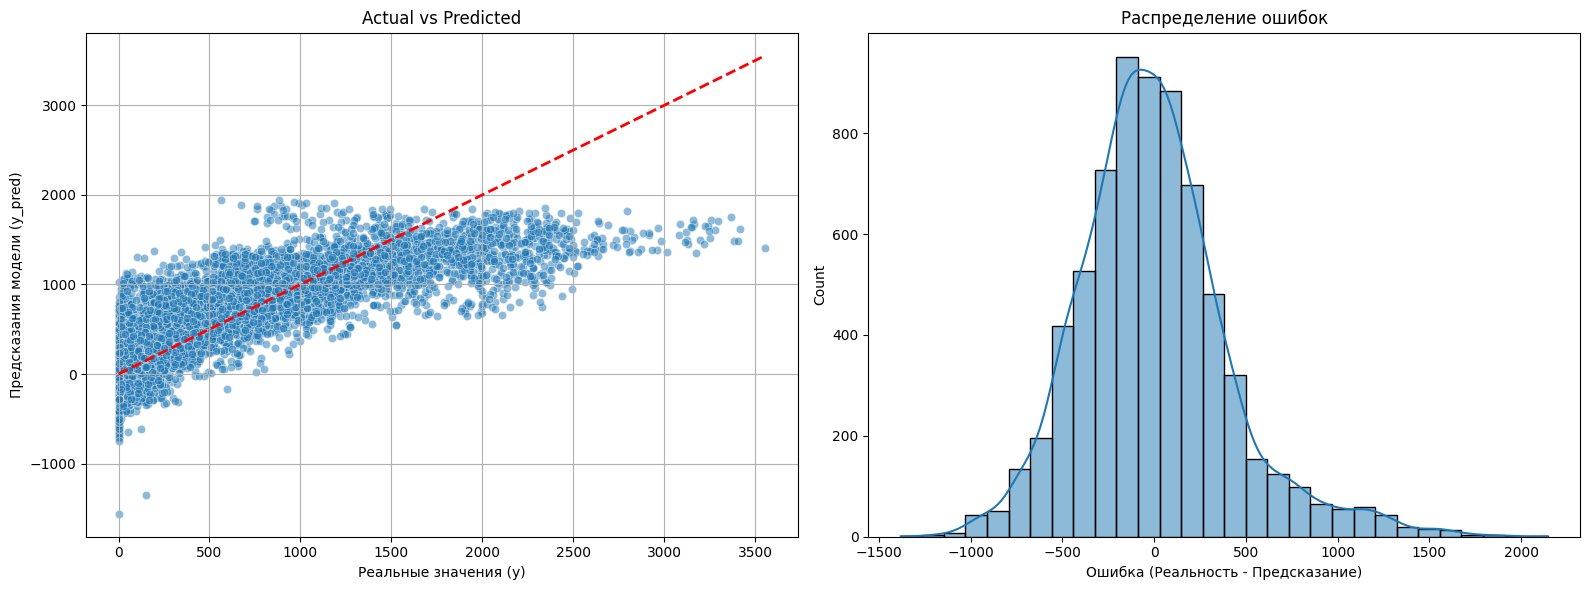

In [8]:
y_pred = baseline.predict(X)

def show_metrics(y, y_pred, name):
    display(pd.DataFrame({
        'Model': name,
        'MSE': mean_squared_error(y, y_pred),
        'RMSE': root_mean_squared_error(y, y_pred),
        'MAE': mean_absolute_error(y, y_pred),
        'R2': r2_score(y, y_pred),
    }, index=[0]))
    
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
    scatter = axes[0]
    sns.scatterplot(x=y, y=y_pred, alpha=0.5, ax=scatter)
    scatter.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)

    scatter.set_title('Actual vs Predicted')
    scatter.set_xlabel('Реальные значения (y)')
    scatter.set_ylabel('Предсказания модели (y_pred)')
    scatter.grid(True)

    errors = y - y_pred
    hist = axes[1]
    sns.histplot(errors, kde=True, bins=30, ax=hist)
    hist.set_title('Распределение ошибок')
    hist.set_xlabel('Ошибка (Реальность - Предсказание)')

    plt.tight_layout()
    plt.show()

show_metrics(y, y_pred, 'Linear Regression (baseline)')

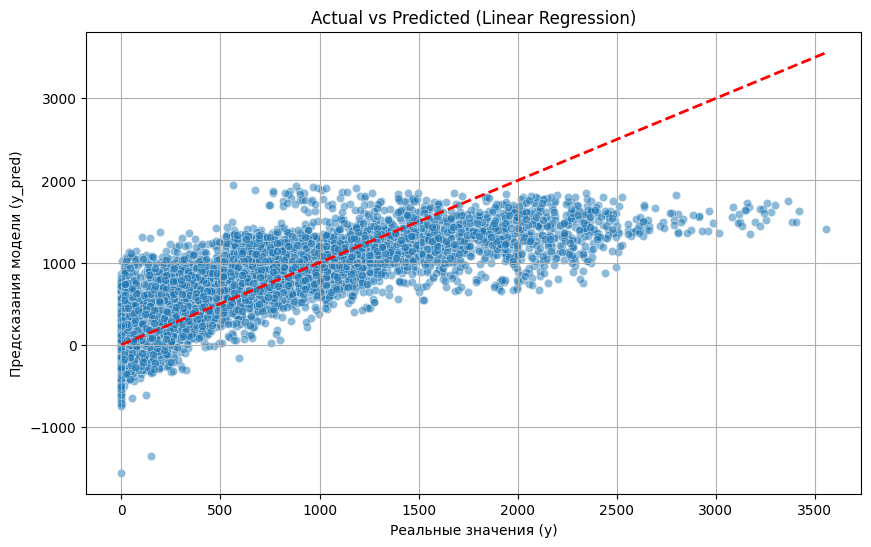

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=y_pred, alpha=0.5)

plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)

plt.title('Actual vs Predicted (Linear Regression)')
plt.xlabel('Реальные значения (y)')
plt.ylabel('Предсказания модели (y_pred)')
plt.grid(True)
plt.show()

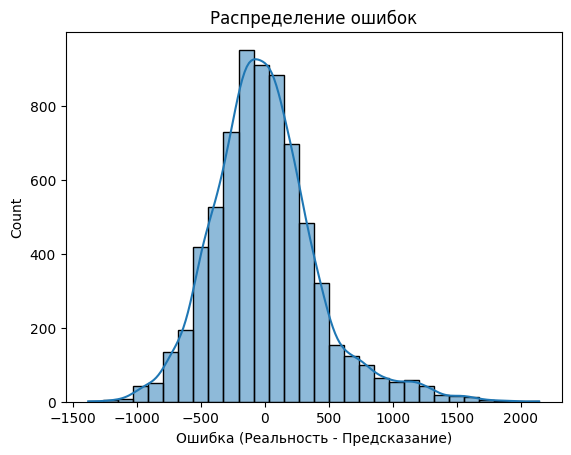

In [10]:
errors = y - y_pred
sns.histplot(errors, kde=True, bins=30)
plt.title('Распределение ошибок')
plt.xlabel('Ошибка (Реальность - Предсказание)')
plt.show()

## **Часть 2. Улучшение модели - kNN и дерево решений**

Ваша задача - предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы погоды и поведение клиентов.

Вы будете экспериментировать с моделями kNN и деревьями решений, используя подбор гиперпараметров Optuna.

**Шаг 1. Изучение данных**

Проведите исследовательский анализ данных:
1. Посмотрите на распределение целевой переменной `Rented Bike Count`. Определите, есть ли у неё выбросы или сильные сезонные колебания.
2. Постройте графики зависимости спроса от разных признаков.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Рассчитайте корреляцию между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять: начните с базовых графиков и описательной статистики.

---

In [11]:
print("Явные дубликаты строк:", train.duplicated().sum())
train = train.drop_duplicates(keep='first')

Явные дубликаты строк: 0


In [12]:
num_cols = train.select_dtypes(include=['number']).columns
cat_cols = train.select_dtypes(include=['str']).columns
bool_cols = train.select_dtypes(include=['bool']).columns

In [13]:
df_eda = train.copy()

In [14]:
rbc = df_eda['Rented Bike Count']

rbc.describe()

count    7008.000000
mean      705.606022
std       646.311790
min         0.000000
25%       190.750000
50%       504.500000
75%      1070.000000
max      3556.000000
Name: Rented Bike Count, dtype: float64

In [15]:
def show_hist(data, name, xlabel='Признак'):    
    ax = data.plot(
        kind='hist',
        title=f'Распределение {name}',
        xlabel=xlabel,
        ylabel='Количетсво',
        rot=30,
        bins=20,
        figsize=(14, 4)
    )

    ax.bar_label(ax.containers[0], label_type='center')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()
    plt.close()

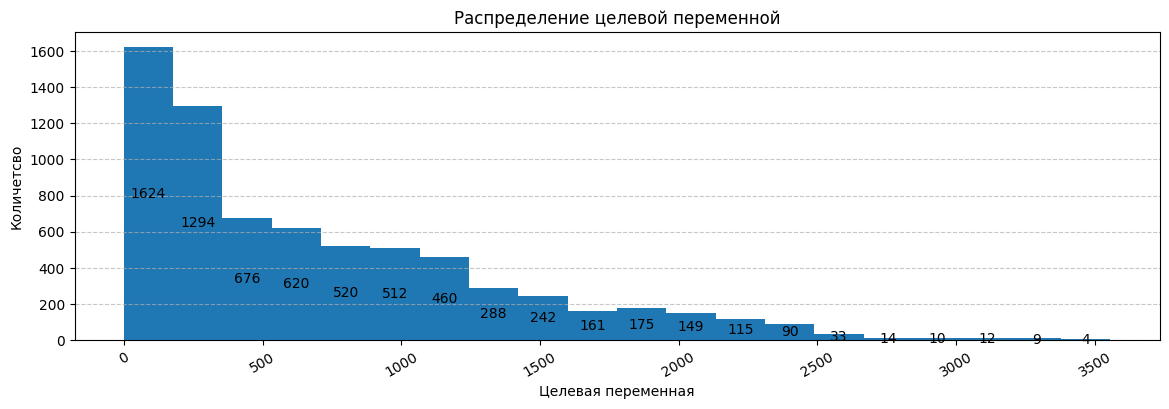

In [16]:
show_hist(rbc, 'целевой переменной', 'Целевая переменная')

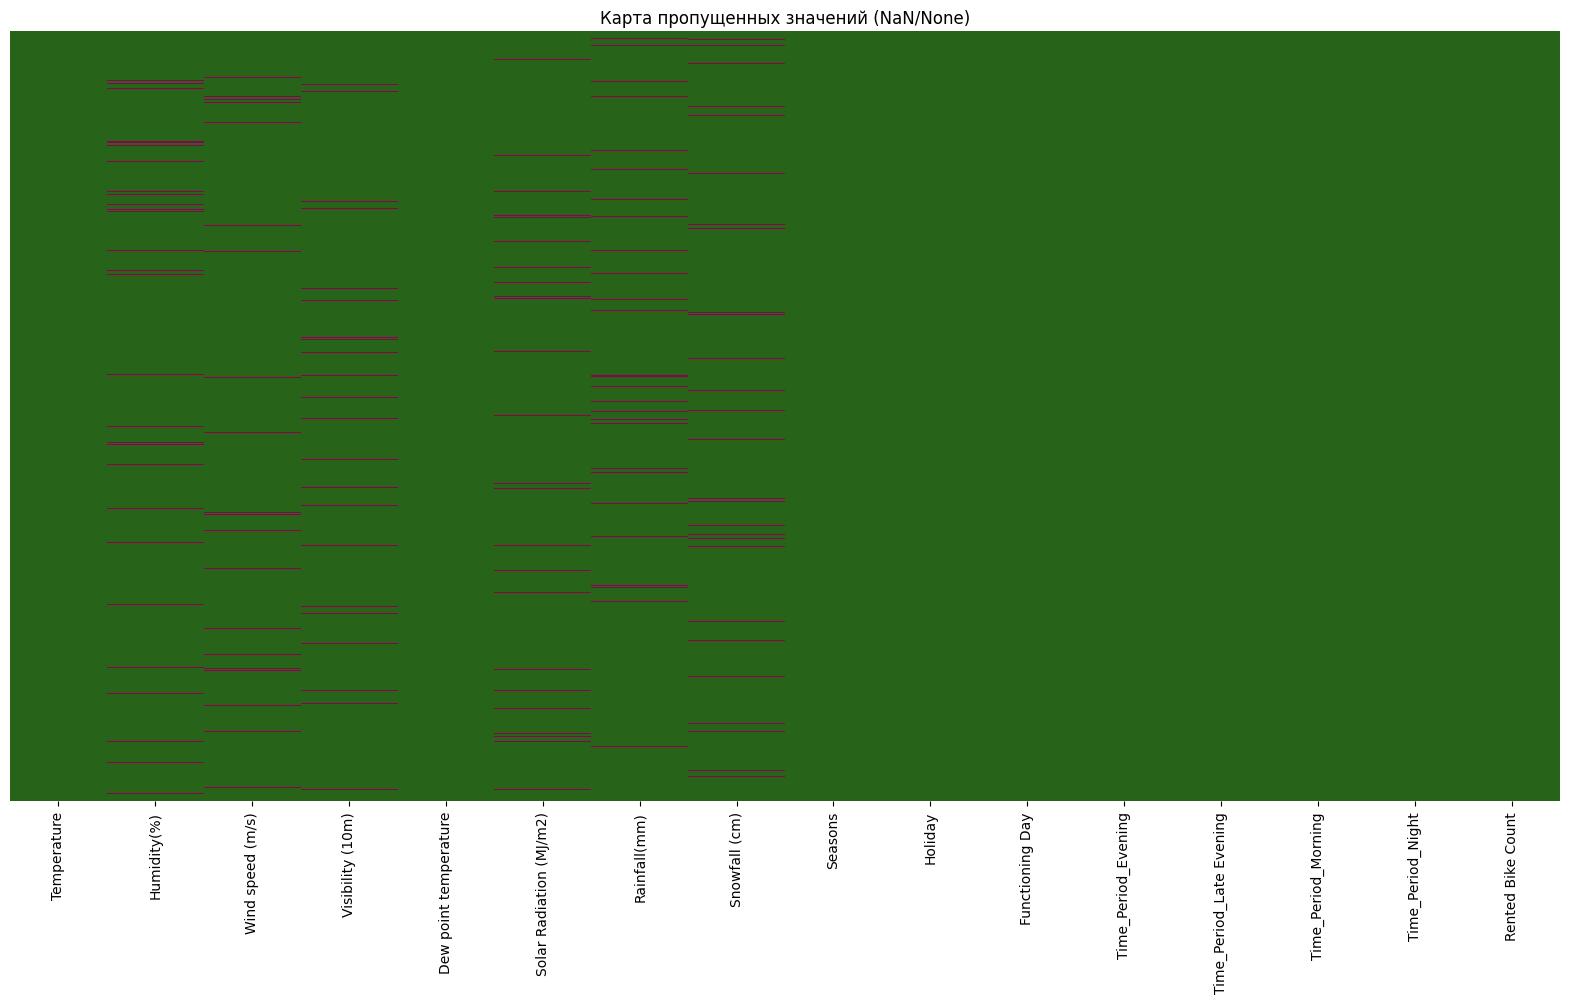

In [17]:
fig, ax = plt.subplots(figsize=(20,10)) 
sns.heatmap(df_eda.isna().astype(int), yticklabels=False, cbar=False, cmap='PiYG_r', xticklabels=df_eda.columns)

plt.title("Карта пропущенных значений (NaN/None)")
plt.show()

In [18]:
def check_num_features(df, cols):
    data = []
    for col in cols:
        data.append({
            'Признак': col,
            'Кол-во': df[col].nunique(),
        })
        
    return pd.DataFrame(data)

check_num_features(df_eda, num_cols)

,Признак,Кол-во
0,Temperature,541
1,Humidity(%),87
2,Wind speed (m/s),64
3,Visibility (10m),1697
4,Dew point temperature,547
5,Solar Radiation (MJ/m2),344
6,Rainfall(mm),53
7,Snowfall (cm),47
8,Rented Bike Count,2024


In [19]:
def create_df_boxplot(data, ax):
    sns.boxplot(data=data, ax=ax)
    
    title = 'Размах значений признака'

    ax.set_title(title)
    ax.set_ylabel('Значение признака')

    ax.grid(True)
    ax.tick_params(axis='x', rotation=30)

In [20]:
def create_df_hist(data, col):
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 2))
    
    hist = axes[0]
    data.plot(
        kind='hist',
        bins=70,
        grid=True,
        ax=hist
    )
    
    hist.set_title(f'Распределение значений признака: {col}')
    hist.set_xlabel('Значение признака')
    hist.set_ylabel('Количество значений')
    hist.set_yscale('log')
    
    create_df_boxplot(data, axes[1])
    
    plt.show()
    plt.close()

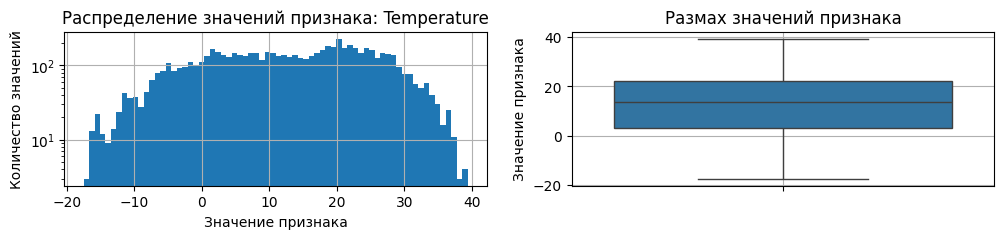

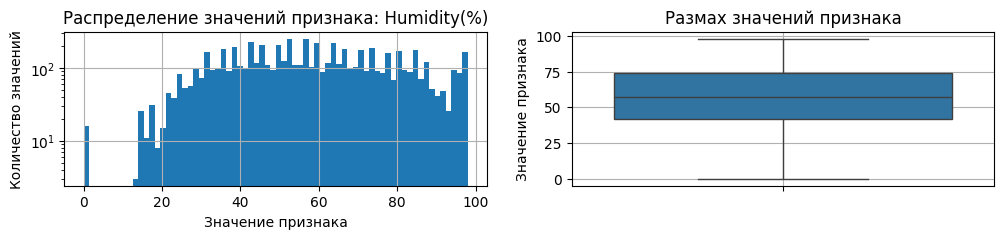

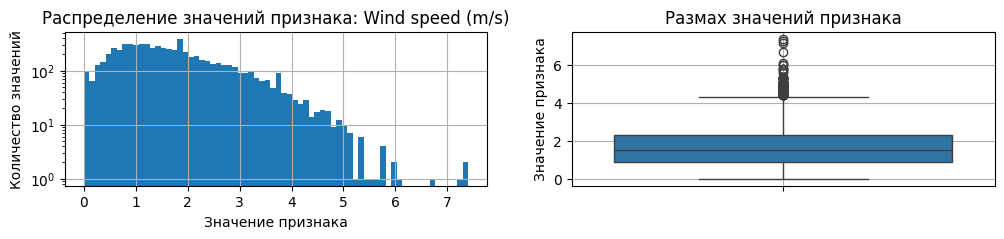

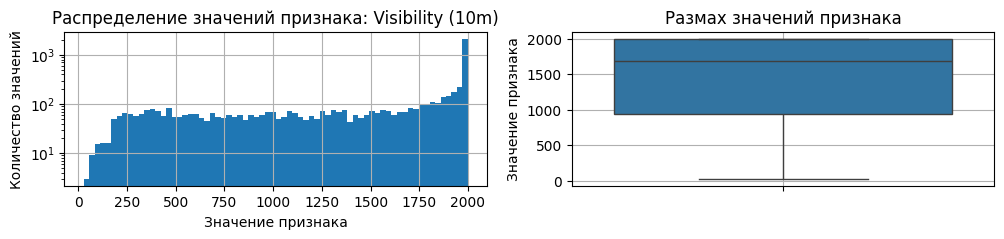

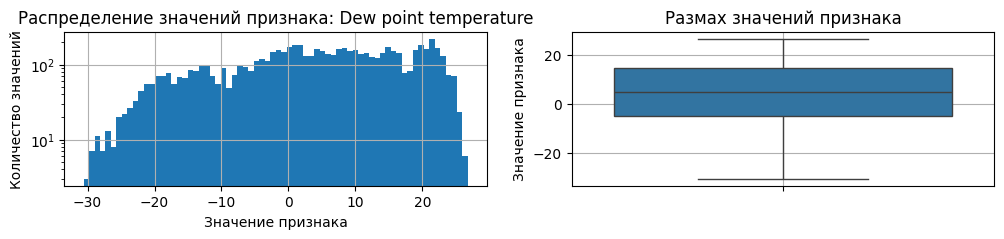

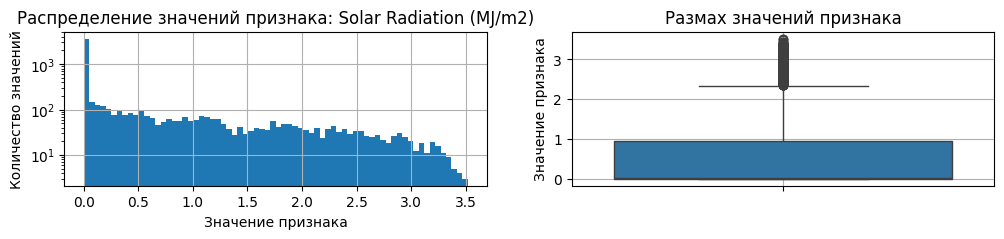

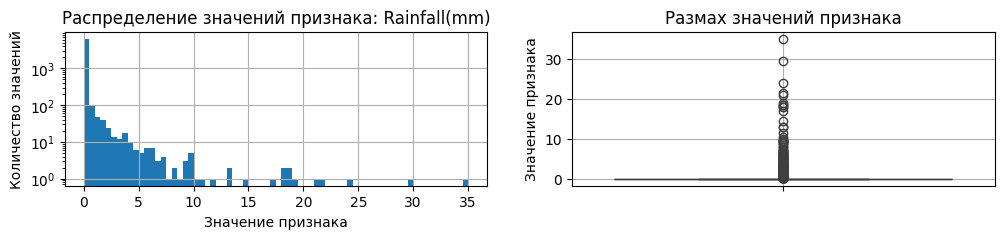

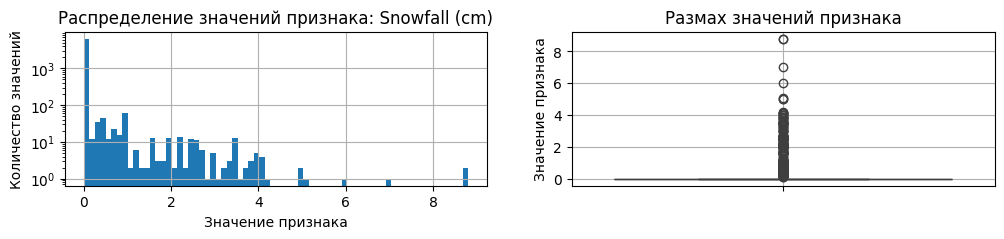

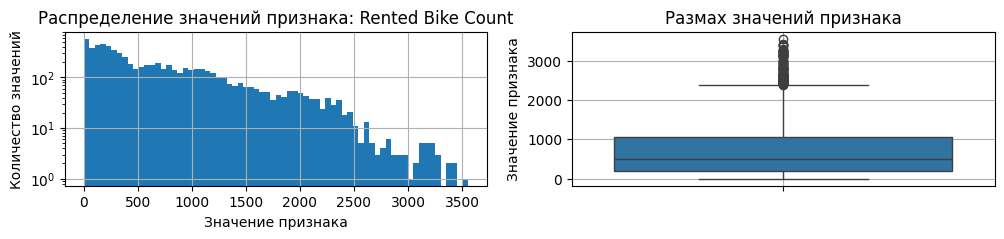

In [21]:
for col in num_cols:
    create_df_hist(df_eda[col], col)

In [22]:
def check_cat_features(df, cols):
    data = []
    for col in cols:
        data.append({
            'Признак': col,
            'Уникальные значения': df[col].unique(),
            'Кол-во': df[col].nunique(),
        })
        
    return pd.DataFrame(data)

check_cat_features(df_eda, cat_cols)

,Признак,Уникальные значения,Кол-во
0,Seasons,"[Autumn, Winter, Summer, Spring]",4
1,Holiday,"[Holiday, No Holiday]",2
2,Functioning Day,"[Yes, No]",2


In [23]:
def show_countplot(df_eda, col):
    plt.figure(figsize=(12, 2)) 
    
    ax = sns.countplot(
        x=col,
        data=df_eda,
        hue=col, 
        legend=False,
        palette='viridis', 
        dodge=False,
    )
    
    plt.title(f'Распределение: {col}')
    plt.xlabel('')
    plt.ylabel('Количество')

    for container in ax.containers:
        ax.bar_label(container, label_type='edge', padding=1)

    plt.tight_layout()
    plt.show()
    
    plt.close()

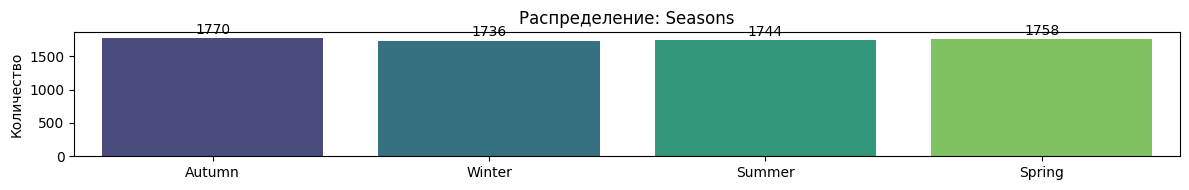

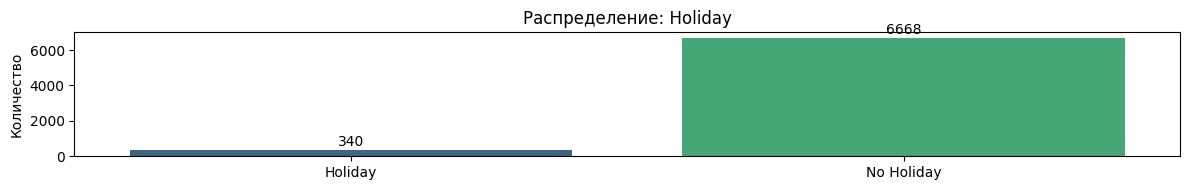

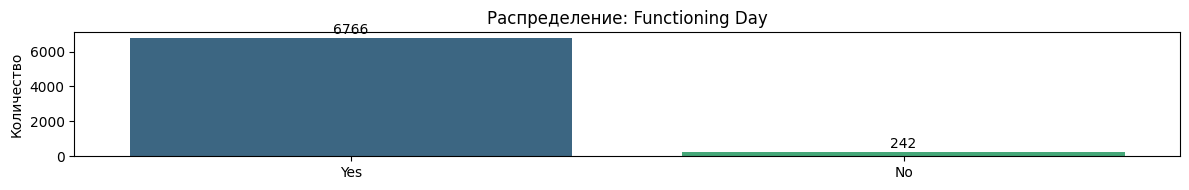

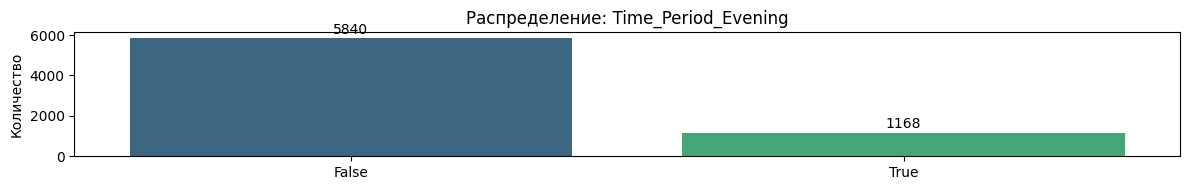

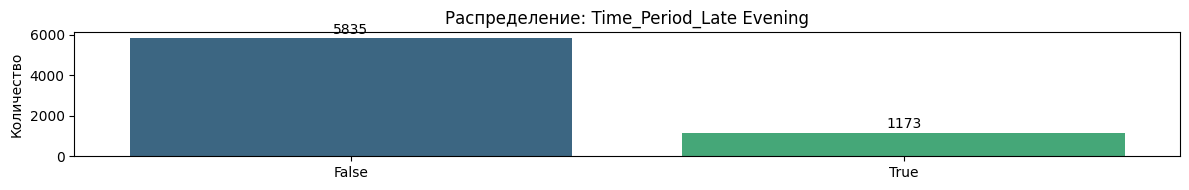

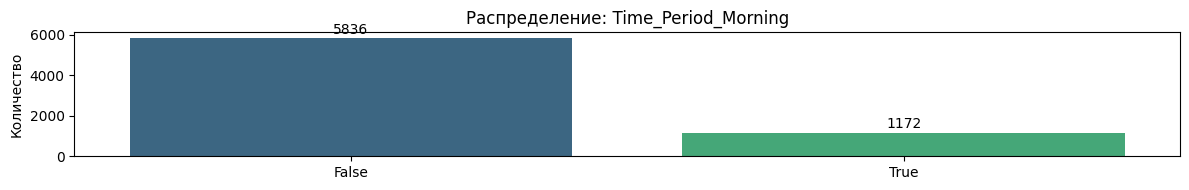

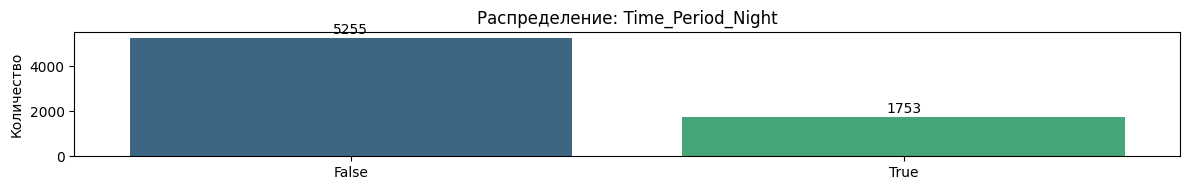

In [24]:
for col in cat_cols.append(bool_cols):
    show_countplot(df_eda, col)

In [25]:
def show_missing_stats(df):
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isna().sum(),
        'Доля пропусков': df.isna().mean() * 100
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    return missing_stats \
            .sort_values(by='Кол-во пропусков', ascending=False) \
            .style.format({'Доля пропусков': '{:.2f}%'}) \
            .background_gradient(cmap='coolwarm')

In [26]:
show_missing_stats(df_eda)

,Кол-во пропусков,Доля пропусков
Snowfall (cm),263,3.75%
Rainfall(mm),262,3.74%
Visibility (10m),259,3.70%
Humidity(%),250,3.57%
Wind speed (m/s),210,3.00%
Solar Radiation (MJ/m2),210,3.00%


In [27]:
cols_to_fix = [
    'Snowfall (cm)', 'Rainfall(mm)', 'Visibility (10m)', 
    'Humidity(%)', 'Wind speed (m/s)', 'Solar Radiation (MJ/m2)'
]

df_eda[cols_to_fix] = df_eda[cols_to_fix].fillna(df_eda[cols_to_fix].median())

In [28]:
show_missing_stats(df_eda)

'Пропусков в данных нет'

In [29]:
def create_heatmap(corr, title, x, y_coef):
    num_rows = len(corr)
    dynamic_height = max(5, num_rows * y_coef) 
    plt.figure(figsize=(x, dynamic_height)) 
    
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=.5,
        cbar=False,
    )
    
    plt.title(title)

    plt.show()

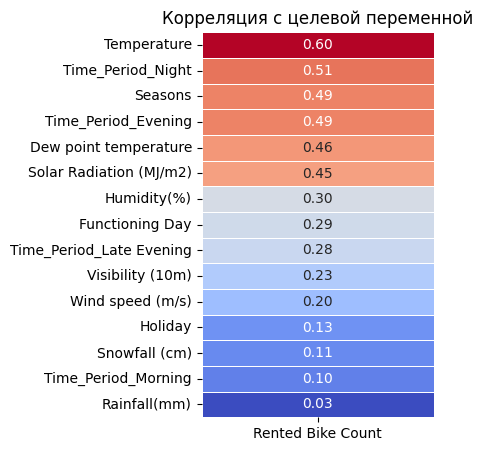

In [30]:
corr_matrix = df_eda.phik_matrix(njobs=4, interval_cols=['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Rented Bike Count'])
target_corr = corr_matrix[corr_matrix.index != 'Rented Bike Count'][['Rented Bike Count']].sort_values(by='Rented Bike Count', ascending=False)

create_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

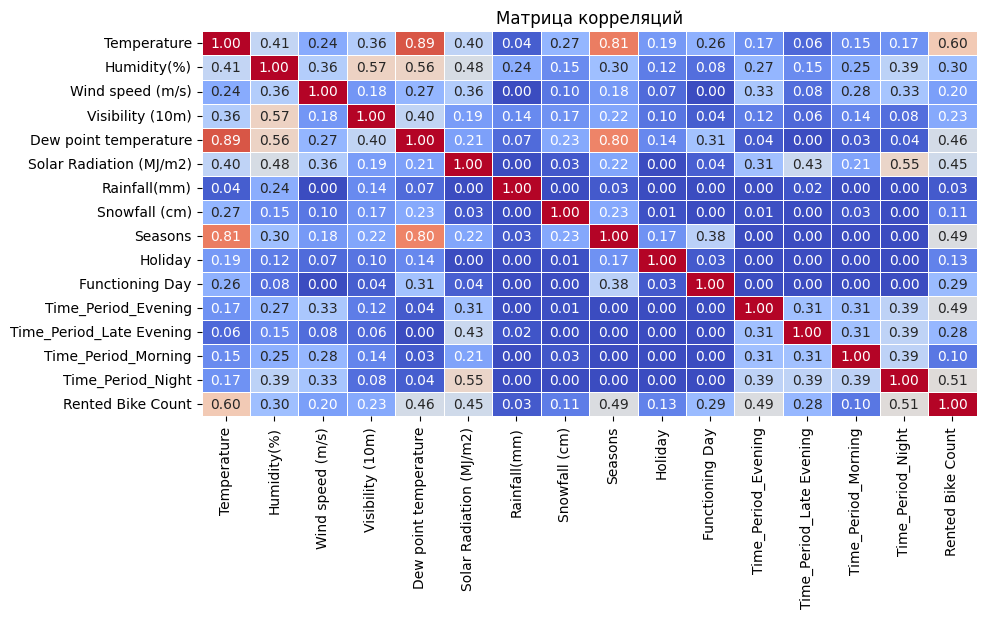

In [31]:
create_heatmap(corr_matrix, title='Матрица корреляций', x=10, y_coef=.3)

Для KNN моделей можно проделать логарифмирование, чтобы улучшить распределение и убрать хвосты на графиках.

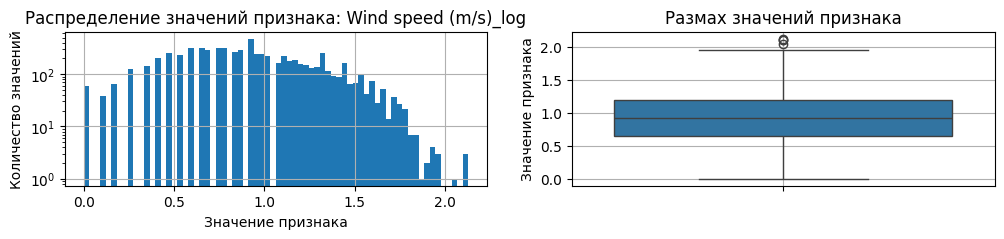

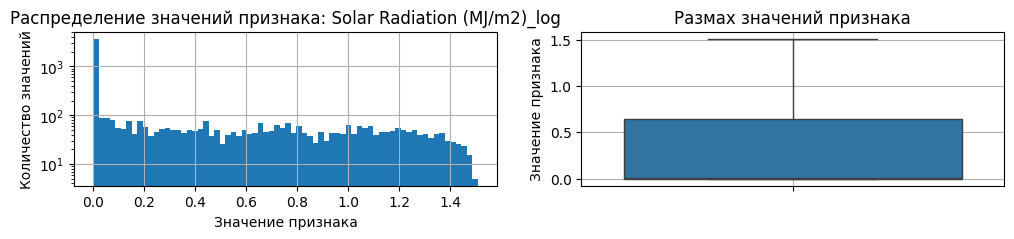

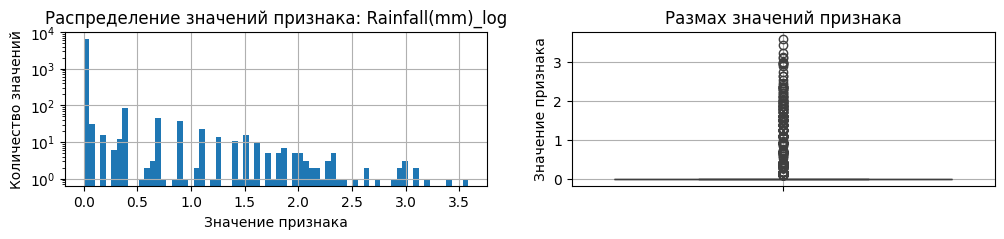

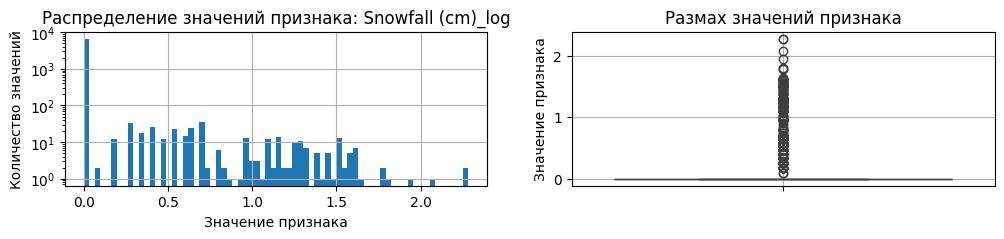

In [32]:
features_with_tails = ['Wind speed (m/s)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
log_col_names = [f'{col}_log' for col in features_with_tails]
df_eda[log_col_names] = df_eda[features_with_tails].apply(np.log1p)

for col in log_col_names:
    create_df_hist(df_eda[col], col)

Для признаков Rainfall и Snowfall логарифмирование не улучшило распределение - удалим признаки _log, но признаки стоит доработать, чтобы модели было проще работать с ними. Стоит преобразовать в категории.

In [33]:
df_eda = df_eda.drop(columns=['Rainfall(mm)_log', 'Snowfall (cm)_log', 'Wind speed (m/s)', 'Solar Radiation (MJ/m2)'])

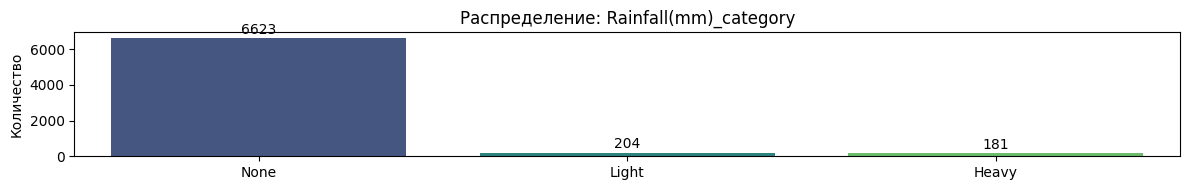

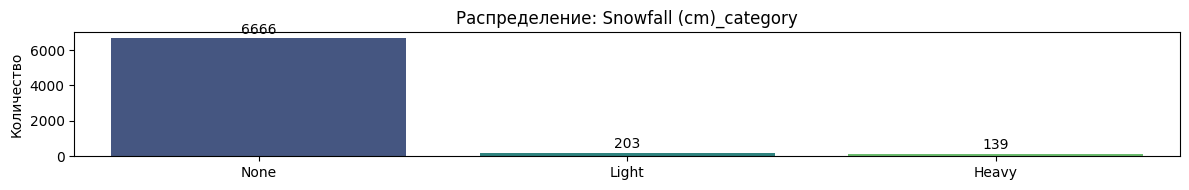

In [34]:
for col in ['Rainfall(mm)', 'Snowfall (cm)']:
    new_col = f"{col}_category"

    df_eda[new_col] = pd.cut(df_eda[col], 
                             bins=[-np.inf, 0, 1, np.inf], 
                             labels=['None', 'Light', 'Heavy'])
    
    df_eda = df_eda.drop(columns=[col])
    
    show_countplot(df_eda, new_col)

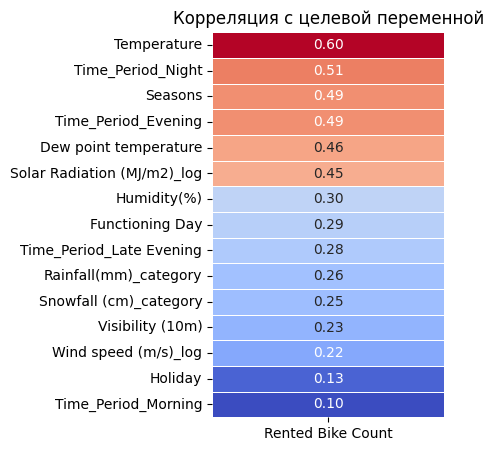

In [35]:
corr_matrix = df_eda.phik_matrix(njobs=4, interval_cols=['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rented Bike Count', 'Wind speed (m/s)_log', 'Solar Radiation (MJ/m2)_log'])
target_corr = corr_matrix[corr_matrix.index != 'Rented Bike Count'][['Rented Bike Count']].sort_values(by='Rented Bike Count', ascending=False)

create_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

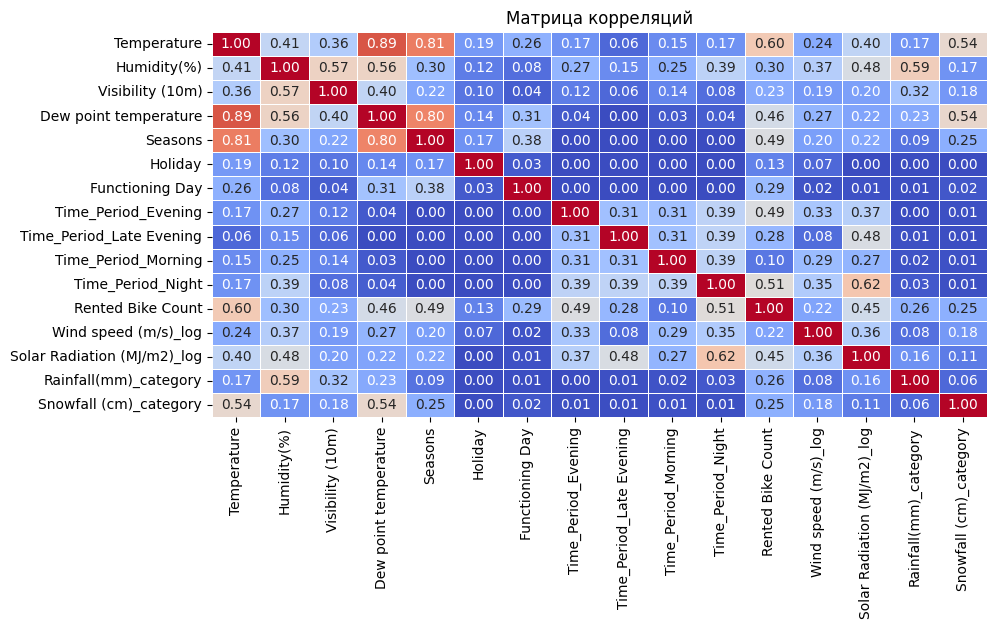

In [36]:
create_heatmap(corr_matrix, title='Матрица корреляций', x=10, y_coef=.3)

Для KNN важно избавиться от корреляции между признаками, поэтому данные столбцы не будут удалены сразу, а только при обучении моделей KNN. Оставить стоит только Temperature, так как данный признак имеет наибольшую корреляция с таргетом. Удаляться будут: 'Seasons', 'Dew point temperature'.

---

**Шаг 2. Разделение данных на тренировочную и валидационную выборки**

Используйте на этом этапе данные файла `ds_s14_train_data.csv`. Тестовый набор нужен только для финальной оценки модели после обучения и подбора гиперпараметров.

Подготовка данных вам понадобится, чтобы обучить модель и оценить её качество через валидацию.

---

In [37]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    shuffle=True,
    test_size=.2,
    random_state=RANDOM_STATE
)

print(f"Размер обучающей выборки: {X_train_val.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Среднее значенее целевой переменной в train: {y_train_val.mean():.3f}")
print(f"Среднее значенее целевой переменной в test: {y_test.mean():.3f}")

Размер обучающей выборки: (5606, 15)
Размер тестовой выборки: (1402, 15)
Среднее значенее целевой переменной в train: 705.099
Среднее значенее целевой переменной в test: 707.633


In [38]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [39]:
target = ['Rented Bike Count']
correlating_features = ['Seasons', 'Dew point temperature']

log_features = ['Wind speed (m/s)', 'Solar Radiation (MJ/m2)']
fall_features = ['Rainfall(mm)', 'Snowfall (cm)']

In [40]:
num_cols = [col for col in num_cols if col not in correlating_features + log_features + fall_features + target]
cat_cols = [col for col in cat_cols if col not in correlating_features]
bool_cols = [col for col in bool_cols if col not in correlating_features]

In [41]:
def bool_to_int(df):
    return df.astype(int)

In [42]:
def fall_binning(X):
    X_df = X.copy()
    for col in X_df.columns:
        X_df[col] = pd.cut(
            X_df[col], 
            bins=[-np.inf, 0, 1, np.inf], 
            labels=['None', 'Light', 'Heavy'],
        )
    return X_df

def get_fall_feature_names(transformer, input_features):
    return input_features 

knn_preprocessor = ColumnTransformer(
    transformers=[
        ('log', make_pipeline(
                SimpleImputer(strategy='constant', fill_value=0),
                FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                StandardScaler()
        ), log_features),
        
        ('num', make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler()
        ), num_cols),
        
        ('fall', make_pipeline(
            FunctionTransformer(fall_binning, feature_names_out=get_fall_feature_names),
            OneHotEncoder(drop='first', sparse_output=False),
        ), fall_features),
        
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
        
        ('bool', FunctionTransformer(bool_to_int, feature_names_out="one-to-one"), bool_cols)
    ],
    remainder='drop'
).set_output(transform="pandas")

In [43]:
X_transformed_df = knn_preprocessor.fit_transform(X_train_val)
X_transformed_df.head()

,log__Wind speed (m/s),log__Solar Radiation (MJ/m2),num__Temperature,num__Humidity(%),num__Visibility (10m),fall__Rainfall(mm)_Light,fall__Rainfall(mm)_None,fall__Rainfall(mm)_nan,fall__Snowfall (cm)_Light,fall__Snowfall (cm)_None,fall__Snowfall (cm)_nan,cat__Holiday_No Holiday,cat__Functioning Day_Yes,bool__Time_Period_Evening,bool__Time_Period_Late Evening,bool__Time_Period_Morning,bool__Time_Period_Night
1741,1.550504,-0.726497,0.527944,0.192249,0.521845,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,1,0,0
3105,0.027521,-0.726497,-0.294434,-0.307843,0.929214,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,1,0,0
1869,-0.657927,-0.726497,-1.544783,1.542495,-1.801669,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0,0,1,0
4643,0.219743,1.246250,0.720951,0.642331,-1.625645,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,0,0,0
387,0.310577,-0.726497,0.402070,-0.057797,-0.842759,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0,0,0,1


In [44]:
knn_pipeline = Pipeline(steps=[
    ('preprocessor', knn_preprocessor),
    ('model', KNeighborsRegressor())
])

,Model,MSE,RMSE,MAE,R2
0,KNN (baseline),129093.541398,359.295897,243.870471,0.687747


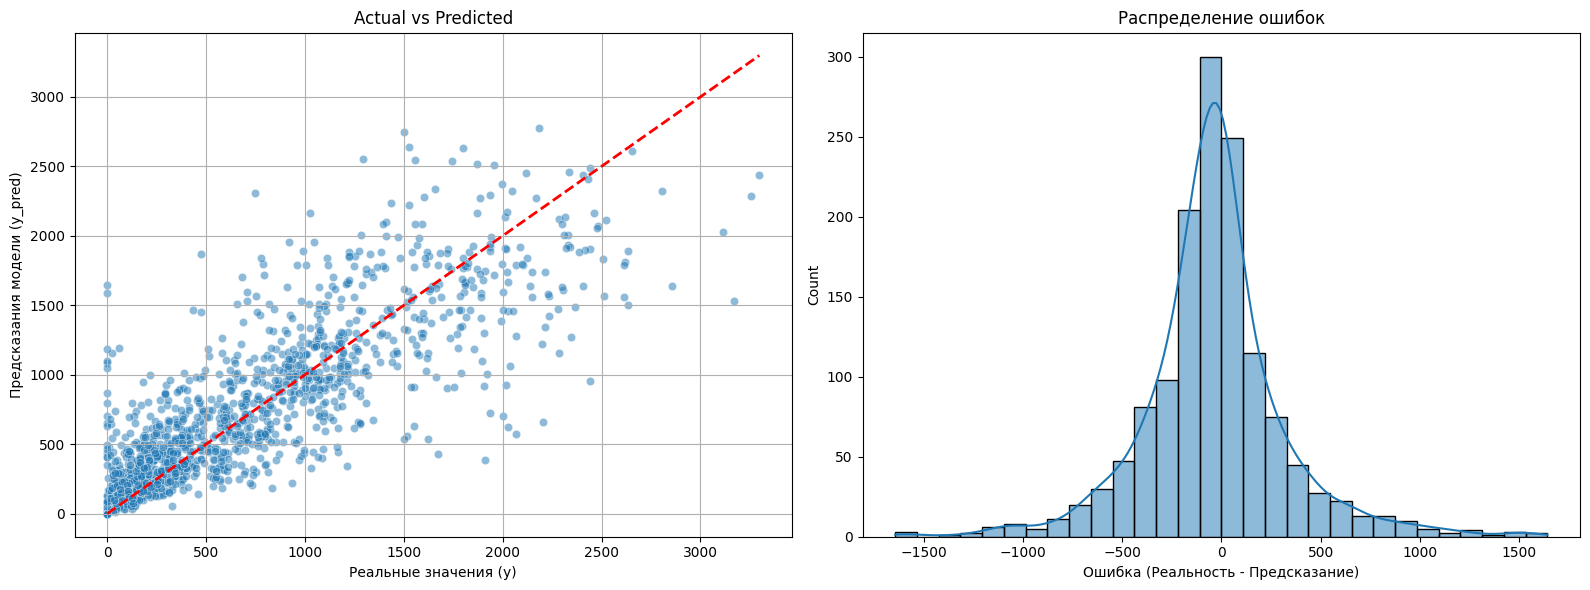

In [45]:
knn_pipeline.fit(X_train_val, y_train_val)
y_pred = knn_pipeline.predict(X_test)
show_metrics(y_test, y_pred, 'KNN (baseline)')

In [46]:
rf_estimator = Ridge(random_state=RANDOM_STATE)

knn_pipeline = Pipeline(steps=[
    ('preprocessor', knn_preprocessor),

    ('var_thresh', VarianceThreshold(threshold=0.001)),
    ('correlation_filter', SelectKBest(score_func=f_regression, k='all')),
    ('rfe', RFE(estimator=rf_estimator, n_features_to_select=.8, step=2)),

    ('model', KNeighborsRegressor())
])

,Model,MSE,RMSE,MAE,R2
0,KNN (filted),111961.388902,334.606319,222.299429,0.729187


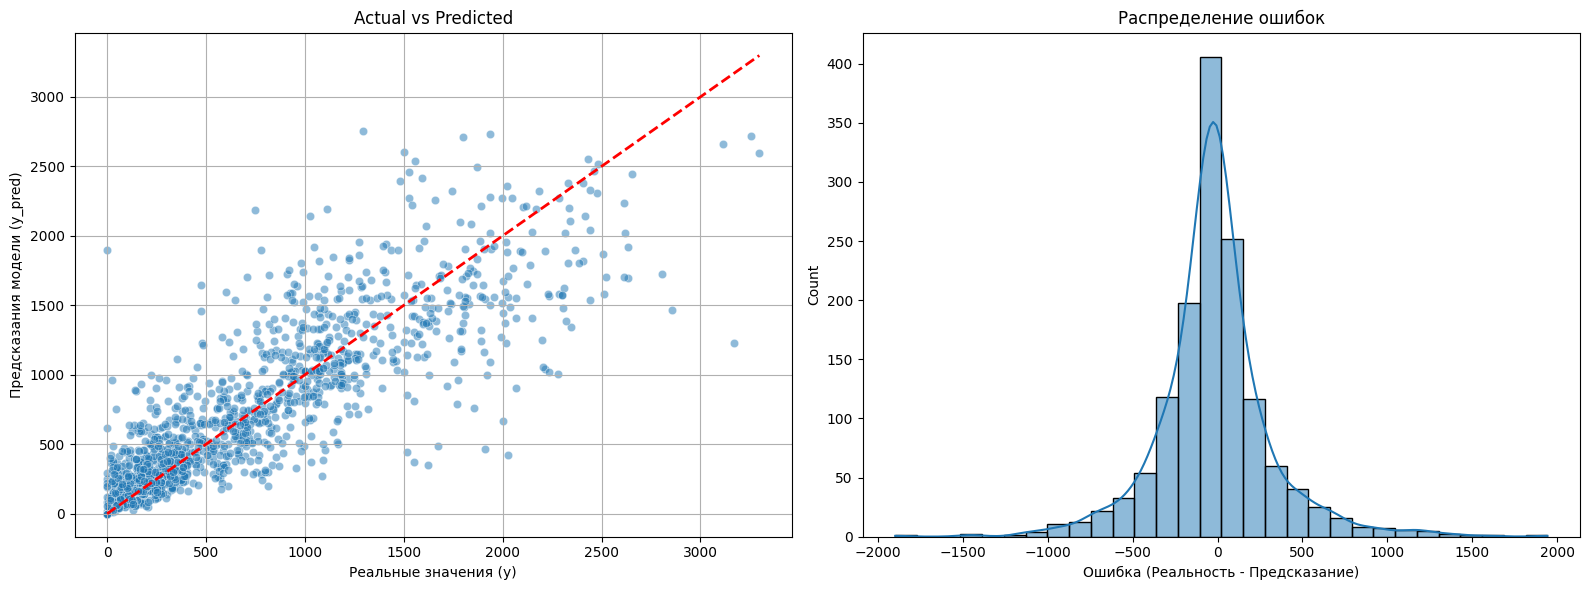

In [ ]:
knn_pipeline.fit(X_train_val, y_train_val)
y_pred = knn_pipeline.predict(X_test)
show_metrics(y_test, y_pred, 'KNN (filted)')

In [ ]:
def objective(trial):
    params = {
        "n_neighbors": trial.suggest_int('n_neighbors', 2, 40),
        "weights": trial.suggest_categorical('weights', ['uniform', 'distance']),
        "p": trial.suggest_int('p', 1, 4)
    }

    model = KNeighborsRegressor(**params, n_jobs=5)
    pipeline = Pipeline([
        ("preprocessor", knn_preprocessor),
        ("model", model)
    ])

    scorer = make_scorer(root_mean_squared_error)

    scores = cross_val_score(
        pipeline,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scorer
    )

    return scores.mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=100, show_progress_bar=True)

fig1 = optuna.visualization.plot_optimization_history(study)
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2) 

best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)
best_value = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", round(best_value, 3))

[I 2026-02-12 00:58:35,120] A new study created in memory with name: no-name-1da633ff-b159-4a99-9767-0c32a20c0e0f
Best trial: 0. Best value: 350.95:   1%|          | 1/100 [00:00<00:34,  2.84it/s]

[I 2026-02-12 00:58:35,472] Trial 0 finished with value: 350.9498050382487 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'p': 3}. Best is trial 0 with value: 350.9498050382487.


Best trial: 1. Best value: 344.964:   2%|▏         | 2/100 [00:00<00:32,  3.00it/s]

[I 2026-02-12 00:58:35,793] Trial 1 finished with value: 344.9636576058357 and parameters: {'n_neighbors': 8, 'weights': 'uniform', 'p': 4}. Best is trial 1 with value: 344.9636576058357.


Best trial: 1. Best value: 344.964:   4%|▍         | 4/100 [00:01<00:24,  3.87it/s]

...

Best trial: 15. Best value: 329.053:  98%|█████████▊| 98/100 [00:14<00:00,  6.11it/s]

[I 2026-02-12 00:58:49,234] Trial 96 finished with value: 337.7214217242038 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 3}. Best is trial 15 with value: 329.05264490385025.
[I 2026-02-12 00:58:49,350] Trial 97 finished with value: 329.83571955420905 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 1}. Best is trial 15 with value: 329.05264490385025.


Best trial: 15. Best value: 329.053: 100%|██████████| 100/100 [00:14<00:00,  6.92it/s]


[I 2026-02-12 00:58:49,468] Trial 98 finished with value: 330.17309290563725 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 1}. Best is trial 15 with value: 329.05264490385025.
[I 2026-02-12 00:58:49,579] Trial 99 finished with value: 331.2063695828057 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'p': 1}. Best is trial 15 with value: 329.05264490385025.


Лучшие гиперпараметры: {'n_neighbors': 10, 'weights': 'distance', 'p': 1}
Лучшее среднее значение RMSE на кросс-валидации: 329.053


,Model,MSE,RMSE,MAE,R2
0,KNN (best params),115765.733339,340.243638,231.982346,0.719985


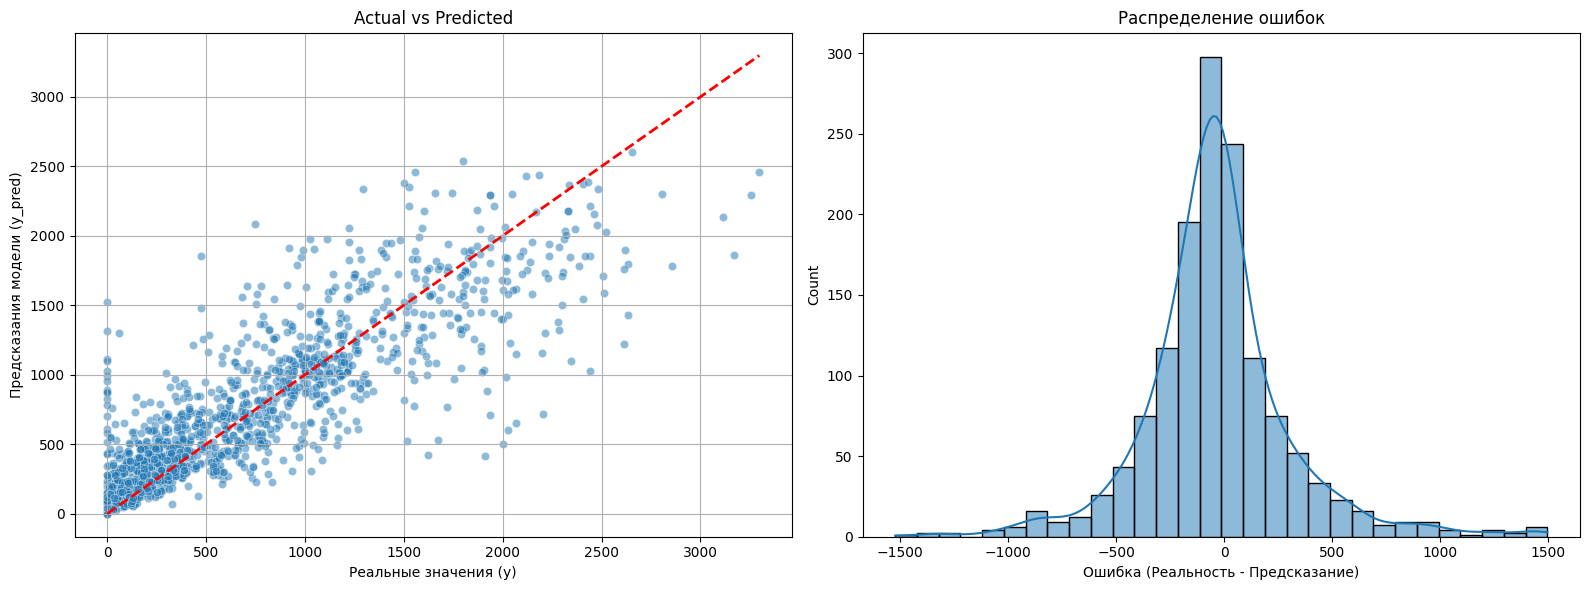

In [52]:
model = KNeighborsRegressor(**study.best_params)
knn_pipeline = Pipeline([
    ("preprocessor", knn_preprocessor),
    ("model", model)
])

knn_pipeline.fit(X_train_val, y_train_val)
y_pred = knn_pipeline.predict(X_test)
show_metrics(y_test, y_pred, 'KNN (best params)')

**Шаг 3. Обучение новых моделей**

kNN и деревья решений могут уловить нелинейные зависимости, недоступные линейной регрессии. Пора это проверить!

1. Подготовьте пайплайн для каждой модели:
    * Выполните предобработку данных.
    * Инициализизируйте регрессионные модели kNN и дерево решений.
4. Настройте базовые параметры моделей - например, `n_neighbors` для kNN, `max_depth` для дерева.

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров вы сделаете на следующем шаге.

---



**Шаг 4. Подбор гиперпараметров с Optuna**

Компания хочет точную модель. Optuna поможет найти лучшие гиперпараметры для kNN и дерева, чтобы снизить ошибки прогноза.


1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь сначала экспериментировать с небольшими диапазонами, а потом расширять их, если модель не уловит зависимости.

---



**Шаг 5. Кросс-валидация новых моделей**

1. Проведите кросс-валидацию kNN и дерева решений с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (например, столбчатую диаграмму или ящик с усами), чтобы оценить разброс метрик и стабильность моделей.


---



**Шаг 6. Составление отчёта по моделям**

1. Составьте таблицу с метриками для трёх моделей: baseline, лучшей kNN и лучшего дерева решений.
2. Добавьте визуализацию с распределением метрик, если необходимо.

Подготовьте выводы:
* Какая модель лучше справляется с прогнозом?
* Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте. Примеры выводов на языке заказчика:
* «Эта модель лучше реагирует на дождь».
* «Температура и влажность сильно влияют на спрос в пиковые часы».

---



**Шаг 7. Сохранение модели и отчёта**

1. Выберите финальную, лучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько хорошо она прогнозирует на новых данных.
2. Подготовьте тетрадку с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг. Объясняйте, почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче эта привычка поможет вашим коллегам и руководству понимать решения и доверять модели.

---



**Дополнительное задание: реализация кастомного трансформера**

Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию. Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

1. Реализуйте класс с методами `fit` и `transform`.
2. Вставьте его в пайплайн перед моделью.
3. Убедитесь, что трансформер корректно работает с тренировочными данными.

**Совет:**  
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---

